In [78]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping
from IPython.display import clear_output

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(8)') 

array([2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

In [29]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles      
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
    end
""")

Main.include("setting.jl")
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\FO.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("Σb.jl")
Main.include("cross section.jl")
Main.include("NP.jl")
Main.include("parallel/fit.jl")

<PyCall.jlwrap model>

In [79]:
error_type = "both"

df_NNLO = pd.read_csv("fixed order/EECNNLO.csv",header=None)

def fixed_error_func(angle: float, df: pd.DataFrame) -> float:
    angles = df.iloc[:, 0]      
    errors = df.iloc[:, 2]       
    
    pos = np.abs(angles.values - angle).argmin()
    return float(errors.iloc[pos])

Data Selection

In [80]:
#-------------------------------------------------------------------
dataset_names = ["OPAL_new","SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

df_original = {}

for name in dataset_names:
    file_path = f"data/{name}.csv"
    df0 = pd.read_csv(file_path)
    
    χ = df0["CHI"]
    EEC = df0["EEC"]
    ERROR = df0["ERROR"]
    Q = df0["Q"]
    BinSize = df0["BinSize"]

    print(Q[0])

    if error_type == "both":
        
        Main.αs_Z = 0.118
        αs = Main.alpha_s_func(Q[0])
        a = αs/(2*np.pi)

        fixed_error=[]
        for angle in χ:
            value = (a**3)*fixed_error_func(angle=angle, df=df_NNLO)
            fixed_error.append(value)
        ERROR = np.sqrt(df0["ERROR"]**2 + np.array(fixed_error)**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "Q": Q, "BinSize": BinSize})
    df_original[name] = df1

91.2
91.2
59.5
53.3
43.5
34.8
29.0
29.0


Range Choice

In [81]:
cut_list = {}
cut_list["sqrtz"] = [0,1/2]

In [82]:
df_truncated = {}

χ = {}
EEC = {}
ERROR = {}
Q = {}
BinSize = {}

df = df_original
for name in dataset_names:
    sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
    kt_list = sqrtz_list*df[name]["Q"]

    if "sqrtz" in cut_list:
        sqrtz_lower, sqrtz_upper = cut_list["sqrtz"]
        df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

    if "kt" in cut_list:
        χ_lower, χ_upper = cut_list["kt"]
        df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

    if "χ" in cut_list:
        kt_lower, kt_upper = cut_list["kt"]
        df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    Q[name] = np.array(df_truncated[name]["Q"])
    BinSize[name] = np.array(df_truncated[name]["BinSize"])

#display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

59

16

16

16

16

16

16

16

In [107]:
n_replicas = 100
If_fit = False
If_scan = True

Random data

In [114]:
#np.random.seed(42)
EEC_list=[]
df_list=[]
for i in range(n_replicas):
    if If_fit == True:
        df = {}
        for name in dataset_names:
            EEC_gaussian = np.random.normal(loc=EEC[name], scale=ERROR[name])
            df[name] = pd.DataFrame({
                "CHI": χ[name], 
                "EEC": EEC_gaussian, 
                "ERROR": ERROR[name],
                "Q": Q[name],                             
                "BinSize": BinSize[name]                
                })
        df_list.append(df)
    else:
        df = {}
        for name in dataset_names:
            EEC_gaussian = EEC[name]
            df[name] = pd.DataFrame({
                "CHI": χ[name], 
                "EEC": EEC[name], 
                "ERROR": ERROR[name],
                "Q": Q[name],                             
                "BinSize": BinSize[name]                
                })
        df_list.append(df)

In [115]:
(df_list[1]["SLD"]["EEC"]-df_list[0]["SLD"]["EEC"])/df_list[0]["SLD"]["ERROR"]

0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
dtype: float64

Random ratios

In [116]:
def custom_random():
    n = np.random.uniform(1.0, 2.0)  
    if np.random.rand() < 0.5:
        return n  
    else:
        return 1 / n  

def random_ratios(n):
    ratio_matrix = pd.DataFrame(columns=['μH_ratio', 'μJ_ratio', 'μren_ratio'])
    
    while len(ratio_matrix) < n:
        
        if If_scan == True:
            μH_ratio, μJ_ratio, μren_ratio = custom_random(), custom_random(), custom_random()
        else:
            μH_ratio, μJ_ratio, μren_ratio = 1.0, 1.0, 1.0

        ratio_matrix.loc[len(ratio_matrix)] = [μH_ratio, μJ_ratio, μren_ratio]
    
    return ratio_matrix

In [117]:
ratios = random_ratios(n_replicas)
n = len(ratios)

In [118]:
display(ratios)

,μH_ratio,μJ_ratio,μren_ratio
0,1.783185,0.760257,0.561676
1,0.504390,1.543456,1.774617
2,1.983270,0.564661,0.606364
3,1.677766,1.810846,1.922561
4,0.826702,0.828123,1.171357
...,...,...,...
95,1.510951,1.277353,0.555305
96,1.037639,1.661940,0.904352
97,0.589447,1.948339,0.562662
98,1.152879,1.328424,1.082125


Chi-Square calculation

In [119]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

Define Objective

In [120]:
def objective(params, df, ratio_list):

    N = 5
    
    chi2 = 0
    N_total = 0
    
    αs = params[0]
    params_noαs = params[1:]

    μJ_ratio=float(ratio_list["μJ_ratio"])
    μH_ratio=float(ratio_list["μH_ratio"])
    μren_ratio=float(ratio_list["μren_ratio"])    

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = {μJ_ratio}')
    Main.eval(f'@everywhere μH_ratio = {μH_ratio}')
    Main.eval(f'@everywhere μren_ratio = {μren_ratio}') 

    dataset_names = df.keys()

    for name in dataset_names:
        xlist={}
        xlist_mid = np.array(df[name]["CHI"])
        binsize = np.array(df[name]["BinSize"]) 
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        data_size = len(xlist_mid)
        N_total = N_total + data_size

        PRED={}

        parameters = params_noαs
        for quartile in range(N):
            PRED[quartile] = Main.model(xlist=xlist[quartile], Qlist=np.array(df[name]["Q"]))   
                         
        DELTA =  DELTA_func(ylist,PRED)                       

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/N_total

Define minimization related

In [121]:
import sys

class ProgressCallback:
    def __init__(self, df, ratio_list):
        self.df = df
        self.dataset_names = dataset_names
        self.ratio_list = ratio_list

    def __call__(self, params):
        chi2_bydof = objective(params, self.df, self.ratio_list)
        sys.stdout.flush()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [122]:
initial_params = [0.118, 0.876, 2.71, 1.11, 1.14]
ratio_list = pd.Series({"μJ_ratio":1.0, "μH_ratio":1.0, "μren_ratio":1.0})
#ratio_list = pd.Series({"μH_ratio":0.5600152145024739, "μJ_ratio":1.9751444820224267, "μren_ratio":1.615623080957798})
0.5600152145024739
objective(initial_params, df_truncated, ratio_list)
# [0.118, 0.886, 2.67, 1.09]
# [0.865, 2.73, 1.14]
# [0.118, 0.876, 2.71, 1.11, 1.14]
# [0.118, 0.835, 2.77, 1.19, 1.37]

2.0975500328266983

Minimization

In [123]:
results_df = pd.DataFrame(columns=['αs', 'params','chi2/dof'])

bounds = [ [0.118 , 0.118], # αs
           #[-1.0 , 1.0  ], # Ω1
            [0.0, 5.0  ], # a1
            [0.0, 5.0  ], # a2
            [0.0, 5.0  ], # a3
            [0.0, 5.0  ], # a3           
        ]

for i in tqdm(range(n_replicas)): 
    
    #Ratios
    ith_row = ratios.iloc[i]
    μH_ratio = ith_row['μH_ratio']    
    μJ_ratio = ith_row['μJ_ratio']
    μren_ratio = ith_row['μren_ratio']

    ratio_list={}
    ratio_list["μH_ratio"]=μH_ratio
    ratio_list["μJ_ratio"]=μJ_ratio
    ratio_list["μren_ratio"]=μren_ratio

    print(ratio_list)
    #Fit
    bounds_T = [list(t) for t in zip(*bounds)]

    progress_callback = ProgressCallback(df_list[i], ratio_list)

    minimizer_kwargs = {
        "method": "L-BFGS-B",
        "bounds": bounds,
        "args": (df_list[i], ratio_list),
        "options": {'maxiter': 100, 'disp': True, "ftol": 10**(-6)},
        "callback": progress_callback
    }

    result = basinhopping(
        objective,
        initial_params,
        minimizer_kwargs=minimizer_kwargs,
        niter=0,
        accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
    )

#-----------------------------------------------------------------------------

    optimal = np.round(result.x,5)
    chi2_per_dof = result.fun

    optimal_params = optimal[1:]

    new_row = pd.Series({
        'αs': optimal[0], 
        'params': optimal_params, 
        'chi2/dof': result.fun,
    })
    results_df = pd.concat([results_df, new_row.to_frame().T], ignore_index=True)
    #print(results_df)
    clear_output()
    
display(results_df)

100%|██████████| 100/100 [58:49<00:00, 35.30s/it]


,αs,params,chi2/dof
0,0.118,"[0.9013, 2.60643, 1.10445, 1.10949]",1.999852
1,0.118,"[0.85569, 2.81426, 1.10666, 1.16163]",2.222975
2,0.118,"[0.90239, 2.52297, 1.10666, 1.10241]",1.989718
3,0.118,"[0.86309, 2.88856, 1.1109, 1.17982]",2.191142
4,0.118,"[0.87175, 2.66539, 1.10918, 1.13493]",2.117998
...,...,...,...
95,0.118,"[0.89567, 2.73519, 1.09892, 1.12353]",2.034333
96,0.118,"[0.87486, 2.81457, 1.09959, 1.1459]",2.107661
97,0.118,"[0.88357, 2.7925, 1.08883, 1.1266]",2.081059
98,0.118,"[0.87327, 2.78285, 1.10587, 1.14751]",2.115284


Store Result to a File

In [124]:
results_df.to_csv("result//temp.csv", index=False)

In [23]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x000001f5a44bcf90>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

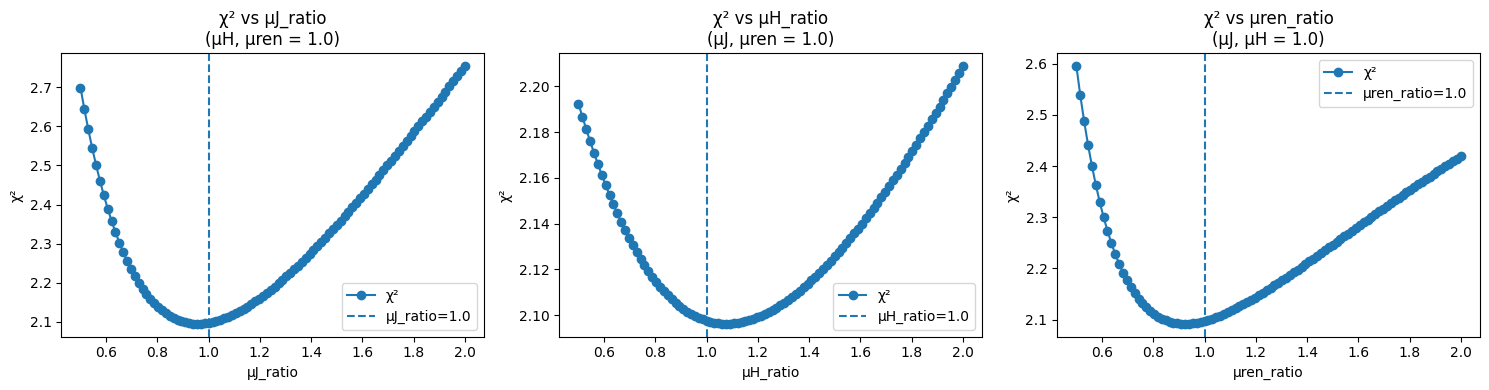

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["text.usetex"] = False

muJ_vals   = np.linspace(0.5, 2.0, 100)
muH_vals   = np.linspace(0.5, 2.0, 100)
muRen_vals = np.linspace(0.5, 2.0, 100)

muJ_chi2   = np.empty_like(muJ_vals)
muH_chi2   = np.empty_like(muH_vals)
muRen_chi2 = np.empty_like(muRen_vals)

for i, μJ in enumerate(muJ_vals):
    ratios = pd.Series({"μJ_ratio": μJ, "μH_ratio": 1.0, "μren_ratio": 1.0})
    muJ_chi2[i] = objective(initial_params, df_truncated, ratios)

for i, μH in enumerate(muH_vals):
    ratios = pd.Series({"μJ_ratio": 1.0, "μH_ratio": μH, "μren_ratio": 1.0})
    muH_chi2[i] = objective(initial_params, df_truncated, ratios)

for i, μren in enumerate(muRen_vals):
    ratios = pd.Series({"μJ_ratio": 1.0, "μH_ratio": 1.0, "μren_ratio": μren})
    muRen_chi2[i] = objective(initial_params, df_truncated, ratios)

# plot all three
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

ax1.plot(muJ_vals,   muJ_chi2,   "o-", label="χ²")
ax1.axvline(1.0, linestyle="--", label="μJ_ratio=1.0")
ax1.set_title("χ² vs μJ_ratio\n(μH, μren = 1.0)")
ax1.set_xlabel("μJ_ratio")
ax1.set_ylabel("χ²")
ax1.legend()

ax2.plot(muH_vals,   muH_chi2,   "o-", label="χ²")
ax2.axvline(1.0, linestyle="--", label="μH_ratio=1.0")
ax2.set_title("χ² vs μH_ratio\n(μJ, μren = 1.0)")
ax2.set_xlabel("μH_ratio")
ax2.set_ylabel("χ²")
ax2.legend()

ax3.plot(muRen_vals, muRen_chi2, "o-", label="χ²")
ax3.axvline(1.0, linestyle="--", label="μren_ratio=1.0")
ax3.set_title("χ² vs μren_ratio\n(μJ, μH = 1.0)")
ax3.set_xlabel("μren_ratio")
ax3.set_ylabel("χ²")
ax3.legend()

plt.show()